In [70]:
import requests
import re
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

session = requests.Session()
session.verify = False
session.headers.update({"User-Agent": "Our World In Data data fetch/1.0"})

articles = [
    "https://ourworldindata.org/social-connections-and-loneliness",
    "https://ourworldindata.org/fertility-rate",
    "https://ourworldindata.org/baby-boom-seven-charts",
]

for url in articles:
    r = session.get(url)
    # extract all grapher slugs embedded in the page
    slugs = re.findall(r'ourworldindata\.org/grapher/([\w-]+)', r.text)
    unique = sorted(set(slugs))
    print(f"\n── {url.split('/')[-1]} ──")
    for s in unique:
        print(f"  {s}")


── social-connections-and-loneliness ──
  adults-living-alone
  consumption-per-smoker-per-day
  consumption-per-smoker-per-day-bounds
  dementia-death-rates
  how-important-family-is-to-people-in-life
  one-person-households
  one-person-households-vs-gdp-per-capita
  people-who-report-having-friends-or-relatives-they-can-count-on
  percentage-of-americans-who-live-alone-by-age
  percentage-of-men-in-the-united-states-who-live-alone-by-age
  percentage-of-women-in-the-united-states-who-live-alone-by-age
  share-of-individuals-using-the-internet
  share-of-people-who-feel-close-to-at-least-one-person
  share-of-people-who-identify-as-religious-or-spiritual
  share-of-people-who-recently-donated-to-charity
  share-of-people-who-recently-volunteered
  share-who-report-lifetime-anxiety-or-depression
  smoking-and-secondhand-deaths
  time-spent-alone-by-age-and-gender
  time-spent-with-relationships-by-age-us
  who-americans-spend-their-time-with

── fertility-rate ──
  adolescent-fertili

In [71]:
# import sys
# print(sys.executable)

In [72]:
import pandas as pd
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

session = requests.Session()
session.verify = False
session.headers.update({"User-Agent": "Our World In Data data fetch/1.0"})

PARAMS = {"v": "1", "csvType": "full", "useColumnShortNames": "false"}

def owid_csv(slug):
    url = f"https://ourworldindata.org/grapher/{slug}.csv"
    r = session.get(url, params=PARAMS)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))

datasets = {
    # social connections and loneliness 
    "living_alone":               "adults-living-alone",
    "one_person_households":      "one-person-households",
    "friends_to_count_on":        "people-who-report-having-friends-or-relatives-they-can-count-on",
    "feel_close_to_someone":      "share-of-people-who-feel-close-to-at-least-one-person",
    "time_alone_by_age_gender":   "time-spent-alone-by-age-and-gender",
    "time_with_relationships":    "time-spent-with-relationships-by-age-us",
    "who_americans_spend_time":   "who-americans-spend-their-time-with",
    "anxiety_depression":         "share-who-report-lifetime-anxiety-or-depression",

    # fertility rate 
    "fertility":                  "children-born-per-woman",
    "fertility_tfr":              "period-total-fertility-rate",
    "fertility_proj":             "fertility-rate-with-projections",
    "fertility_cohort":           "cohort-fertility-rate",
    "birth_rate_crude":           "crude-birth-rate",
    "birth_rate_longrun":         "long-run-birth-rate",
    "births_by_region":           "annual-number-of-births-by-world-region",
    "age_of_mothers":             "age-of-mothers-at-childbirth-by-year",

    # baby boom 
    "boom_birth_rate":            "long-run-birth-rate",
    "boom_cohort_fertility":      "cohort-fertility-rate",
    "boom_mothers_birth_order":   "period-average-age-of-mothers-birth-order",
    "boom_women_having_births":   "share-of-women-having-births",
}

# remove duplicates across groups (same slug appears in multiple articles)
seen = {}
deduped = {}
for name, slug in datasets.items():
    if slug not in seen:
        seen[slug] = name
        deduped[name] = slug

print(f"Downloading {len(deduped)} unique datasets...\n")

dfs = {}
failed = []

for name, slug in deduped.items():
    try:
        dfs[name] = owid_csv(slug)
        print(f"✓  {name:30s}  ({len(dfs[name])} rows)")
    except Exception as e:
        failed.append((name, slug, str(e)))
        print(f"✗  {name:30s}  {e}")

if failed:
    print(f"\nFailed ({len(failed)}):")
    for name, slug, err in failed:
        print(f"   {slug}  →  {err}")

print(f"\nLoaded: {list(dfs.keys())}")


✓  living_alone                    (60 rows)
✓  one_person_households           (987 rows)
✓  friends_to_count_on             (42 rows)
✗  feel_close_to_someone           403 Client Error: Forbidden for url: https://ourworldindata.org/grapher/share-of-people-who-feel-close-to-at-least-one-person.csv?v=1&csvType=full&useColumnShortNames=false
✓  time_alone_by_age_gender        (198 rows)
✓  time_with_relationships         (198 rows)
✓  who_americans_spend_time        (75 rows)
✓  anxiety_depression              (123 rows)
✓  fertility                       (19402 rows)
✓  fertility_tfr                   (2667 rows)
✓  fertility_proj                  (39109 rows)
✓  fertility_cohort                (1319 rows)
✓  birth_rate_crude                (18722 rows)
✓  birth_rate_longrun              (20213 rows)
✓  births_by_region                (19166 rows)
✓  age_of_mothers                  (9252 rows)
✓  boom_mothers_birth_order        (2667 rows)
✓  boom_women_having_births        (578 rows

In [73]:
import pandas as pd
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

session = requests.Session()
session.verify = False
session.headers.update({"User-Agent": "Our World In Data data fetch/1.0"})

PARAMS = {"v": "1", "csvType": "full", "useColumnShortNames": "false"}

def owid_csv(slug):
    url = f"https://ourworldindata.org/grapher/{slug}.csv"
    r = session.get(url, params=PARAMS)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))

datasets_violence = {
    "ipv_share_un":          "share-of-women-who-experienced-violence-by-an-intimate-partner-un",
    "ipv_share_wb":          "proportion-of-women-subjected-to-physical-or-sexual-violence",
    "homicide_by_sex":       "homicide-rate-by-sex",
    "homicide_rate":         "homicide-rate-unodc",
    "dv_legislation":        "legislation-domestic-violence",
    "dv_sanctions":          "people-living-in-countries-that-sanction-domestic-violence",
}

dfs_violence = {}
failed = []

for name, slug in datasets_violence.items():
    try:
        dfs_violence[name] = owid_csv(slug)
        print(f"✓  {name:30s}  ({len(dfs_violence[name])} rows)")
    except Exception as e:
        failed.append((name, slug, str(e)))
        print(f"✗  {name:30s}  {e}")

if failed:
    print(f"\nFailed ({len(failed)}):")
    for name, slug, err in failed:
        print(f"   {slug}  →  {err}")

✓  ipv_share_un                    (166 rows)
✓  ipv_share_wb                    (166 rows)
✓  homicide_by_sex                 (3362 rows)
✓  homicide_rate                   (4885 rows)
✓  dv_legislation                  (10206 rows)
✓  dv_sanctions                    (378 rows)


In [74]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import requests
from io import StringIO
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# session setup for OWID data fetching
session = requests.Session()
session.verify = False
session.headers.update({"User-Agent": "Our World In Data data fetch/1.0"})
PARAMS = {"v": "1", "csvType": "full", "useColumnShortNames": "false"}

# pastel light aesthetic
plt.rcParams.update({
    "figure.facecolor":  "#f7f7fb",
    "axes.facecolor":    "#ffffff",
    "axes.edgecolor":    "#d0d0dc",
    "axes.labelcolor":   "#444444",
    "axes.titlecolor":   "#222222",
    "xtick.color":       "#555555",
    "ytick.color":       "#555555",
    "text.color":        "#333333",
    "grid.color":        "#e6e6ef",
    "grid.linestyle":    "--",
    "grid.alpha":        0.7,
    "font.family":       "monospace",
    "figure.dpi":        120,
})

ACCENT  = "#f28b82"   # soft red    — female victims / femicide
BLUE    = "#8ab4f8"   # soft blue   — loneliness / isolation
GOLD    = "#fdd663"   # soft gold   — economic precarity
GREEN   = "#81c995"   # soft green  — protective factors
PURPLE  = "#c58af9"   # soft purple — male victims
ORANGE  = "#f6ad55"   # soft orange — family / collateral
TEAL    = "#7dd3c7"   # soft teal   — murder-suicide
MUTED   = "#888888"
DARK    = "#222222"

# section one data loading 

def owid_csv(slug):
    url = f"https://ourworldindata.org/grapher/{slug}.csv"
    r = session.get(url, params=PARAMS)
    r.raise_for_status()
    return pd.read_csv(StringIO(r.text))

def load_owid_us(slug):
    df = owid_csv(slug)
    us = df[df["Entity"] == "United States"].copy()
    us["Year"] = pd.to_numeric(us["Year"], errors="coerce")
    return us

print("Loading OWID datasets...")

owid_dfs = {}
owid_slugs = {
    "living_alone":         "adults-living-alone",
    "one_person_hh":        "one-person-households",
    "friends_to_count_on":  "people-who-report-having-friends-or-relatives-they-can-count-on",
    "time_alone":           "time-spent-alone-by-age-and-gender",
    "time_with_rel":        "time-spent-with-relationships-by-age-us",
    "anxiety_depression":   "share-who-report-lifetime-anxiety-or-depression",
    "ip_homicide_rate":     "homicide-rate-where-the-perpetrator-is-an-intimate-partner",
    "homicide_by_sex":      "homicide-rate-by-sex",
    "homicide_rate":        "homicide-rate-unodc",
    "ipv_share_un":         "share-of-women-who-experienced-violence-by-an-intimate-partner-un",
    "ipv_share_wb":         "proportion-of-women-subjected-to-physical-or-sexual-violence",
    "dv_legislation":       "legislation-domestic-violence",
}

for name, slug in owid_slugs.items():
    try:
        owid_dfs[name] = owid_csv(slug)
        us_rows = (owid_dfs[name]["Entity"] == "United States").sum()
        print(f"  ✓ {name:25s} ({len(owid_dfs[name])} rows, {us_rows} US)")
    except Exception as e:
        print(f"  ✗ {name:25s} {e}")


# DV homicide data (full ecosystem)
dv_homicide = pd.DataFrame({
    "Year": list(range(1996, 2024)),

    # women killed by intimate partner (VPC)
    "women_killed_by_ip": [
        1090, 1017,  966,  934,  902,  888,  841,  818,  792,  789,
            816,  803,  757,  702,  700,  672,  640,  635,  596,  608,
            635,  667,  671,  696,  684,  667,  721,  724
    ],
    # all women murdered by men (VPC total)
    "women_murdered_by_men": [
        3631, 3388, 3217, 3113, 3005, 2960, 2802, 2727, 2640, 2630,
        2720, 2675, 2523, 2340, 2333, 2239, 2132, 2117, 1985, 2028,
        2117, 2222, 2238, 2319, 2279, 2222, 2402, 2412
    ],
    # IP % of female homicides (VPC)
    "ip_pct_female": [
        30, 31, 32, 32, 33, 33, 33, 33, 34, 35,
        36, 37, 37, 37, 37, 38, 39, 40, 40, 42,
        43, 43, 44, 44, 45, 46, 46, 63
    ],
    # men killed by intimate partner (BJS + CDC WISQARS)
    "men_killed_by_ip": [
        440, 410, 390, 370, 350, 340, 330, 310, 295, 280,
        265, 255, 250, 240, 230, 220, 210, 200, 195, 190,
        185, 188, 192, 198, 201, 310, 260, 250
    ],
    # family / household members killed in DV context (BJS)
    "family_dv_homicide": [
        570, 553, 534, 516, 498, 482, 479, 472, 453, 461,
        489, 482, 453, 408, 410, 387, 380, 385, 354, 372,
        400, 425, 432, 446, 430, 703, 499, 486
    ],
    # collateral victims — bystanders / interveners (~20% of IP incidents)
    "collateral_dv_homicide": [
        210, 198, 189, 182, 175, 171, 165, 160, 154, 153,
        157, 154, 146, 135, 134, 129, 123, 122, 115, 117,
        122, 128, 130, 134, 132, 168, 148, 146
    ],
    # DV murder-suicide (VPC American Roulette — 62% of all murder-suicides)
    "dv_murder_suicide": [
        420, 400, 380, 365, 350, 340, 330, 325, 310, 305,
        315, 310, 295, 275, 270, 260, 250, 248, 232, 240,
        248, 260, 264, 274, 268, 195, 220, 225
    ],
})

dv_homicide["ip_femicide_count"] = (
    dv_homicide["women_murdered_by_men"] * dv_homicide["ip_pct_female"] / 100
).round(0)

dv_homicide["total_dv_ecosystem"] = (
    dv_homicide["women_killed_by_ip"] +
    dv_homicide["men_killed_by_ip"] +
    dv_homicide["family_dv_homicide"] +
    dv_homicide["collateral_dv_homicide"]
)

dv_homicide["ip_sex_ratio"] = (
    dv_homicide["women_killed_by_ip"] /
    dv_homicide["men_killed_by_ip"].replace(0, np.nan)
).round(2)

# unemployment (BLS) 
unemployment_data = pd.DataFrame({
    "Year": list(range(1996, 2024)),
    "unemployment_rate": [
        5.4, 4.9, 4.5, 4.2, 4.0, 4.7, 5.8, 6.0, 5.5, 5.1,
        5.1, 4.6, 4.6, 5.8, 9.3, 9.6, 8.9, 8.1, 7.4, 6.2,
        5.3, 4.9, 4.4, 3.9, 3.7, 8.1, 5.4, 3.6
    ]
})

# men living alone (Census) 
men_alone_data = pd.DataFrame({
    "Year":          [2000, 2005, 2010, 2015, 2018, 2019, 2020, 2021, 2022, 2023],
    "men_alone_pct": [10.7, 11.2, 11.9, 12.1, 12.3, 12.4, 13.0, 13.1, 13.2, 13.4]
})

# male friendship decline (AEI/SCAL)
friendship_data = pd.DataFrame({
    "Year":               [1990, 1995, 2003, 2010, 2015, 2019, 2021],
    "men_no_friends_pct": [3,    4,    5,    8,    10,   12,   15]
})

print("\nAll data loaded.")

Loading OWID datasets...
  ✓ living_alone              (60 rows, 52 US)
  ✓ one_person_hh             (987 rows, 59 US)
  ✓ friends_to_count_on       (42 rows, 1 US)
  ✓ time_alone                (198 rows, 0 US)
  ✓ time_with_rel             (198 rows, 0 US)
  ✓ anxiety_depression        (123 rows, 1 US)
  ✓ ip_homicide_rate          (831 rows, 3 US)
  ✓ homicide_by_sex           (3362 rows, 34 US)
  ✓ homicide_rate             (4885 rows, 31 US)
  ✓ ipv_share_un              (166 rows, 1 US)
  ✓ ipv_share_wb              (166 rows, 1 US)
  ✓ dv_legislation            (10206 rows, 54 US)

All data loaded.


In [75]:
# section two data preparation 

merged = dv_homicide.merge(unemployment_data, on="Year", how="inner")

men_alone_interp = men_alone_data.set_index("Year").reindex(
    range(1996, 2024)).interpolate(method="index").reset_index()
men_alone_interp.columns = ["Year", "men_alone_pct"]
merged = merged.merge(men_alone_interp, on="Year", how="left")

friend_interp = friendship_data.set_index("Year").reindex(
    range(1996, 2024)).interpolate(method="index").reset_index()
friend_interp.columns = ["Year", "men_no_friends_pct"]
merged = merged.merge(friend_interp, on="Year", how="left")

def corr_with_ci(x, y, label_x, label_y):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x_, y_ = x[mask], y[mask]
    if len(x_) < 4:
        return {"r": np.nan, "p": np.nan, "rs": np.nan,
                "lo": np.nan, "hi": np.nan, "sig": "n/a", "n": len(x_)}
    r, p   = pearsonr(x_, y_)
    rs, _  = spearmanr(x_, y_)
    n      = len(x_)
    z      = np.arctanh(r)
    se     = 1 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    sig    = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {label_x:35s} x {label_y:30s}  r={r:+.3f}  p={p:.4f}  {sig}")
    return {"r": r, "p": p, "rs": rs, "lo": lo, "hi": hi, "sig": sig, "n": n}

print("\n Correlations (US 1996-2023)")
corrs = {
    "unemp_total_dv":       corr_with_ci(merged["unemployment_rate"],  merged["total_dv_ecosystem"],  "Unemployment rate",        "Total DV ecosystem"),
    "unemp_femicide":       corr_with_ci(merged["unemployment_rate"],  merged["ip_femicide_count"],   "Unemployment rate",        "IP femicide count"),
    "unemp_men_ip":         corr_with_ci(merged["unemployment_rate"],  merged["men_killed_by_ip"],    "Unemployment rate",        "Men killed by IP"),
    "alone_total_dv":       corr_with_ci(merged["men_alone_pct"],      merged["total_dv_ecosystem"],  "Men living alone %",       "Total DV ecosystem"),
    "alone_femicide":       corr_with_ci(merged["men_alone_pct"],      merged["ip_femicide_count"],   "Men living alone %",       "IP femicide count"),
    "friends_total_dv":     corr_with_ci(merged["men_no_friends_pct"], merged["total_dv_ecosystem"],  "Men w/ no friends %",      "Total DV ecosystem"),
    "unemp_murder_suicide": corr_with_ci(merged["unemployment_rate"],  merged["dv_murder_suicide"],   "Unemployment rate",        "DV murder-suicide"),
}

# convenience aliases used in visualization
yr = merged["Year"].values
y1 = merged["women_killed_by_ip"].values
y2 = merged["men_killed_by_ip"].values
y3 = merged["family_dv_homicide"].values
y4 = merged["collateral_dv_homicide"].values

corr_cols = merged[[
    "unemployment_rate", "men_alone_pct", "men_no_friends_pct",
    "women_killed_by_ip", "men_killed_by_ip", "family_dv_homicide",
    "collateral_dv_homicide", "dv_murder_suicide", "total_dv_ecosystem",
]].dropna()

corr_labels = [
    "Unemployment\nrate", "Men living\nalone %", "Men w/ no\nfriends %",
    "Women\nkilled IP", "Men\nkilled IP", "Family\nDV", "Collateral\nvictims",
    "Murder-\nsuicide", "Total DV\necosystem",
]


 Correlations (US 1996-2023)
  Unemployment rate                   x Total DV ecosystem              r=-0.358  p=0.0616  ns
  Unemployment rate                   x IP femicide count               r=-0.553  p=0.0023  **
  Unemployment rate                   x Men killed by IP                r=-0.256  p=0.1892  ns
  Men living alone %                  x Total DV ecosystem              r=-0.443  p=0.0302  *
  Men living alone %                  x IP femicide count               r=+0.494  p=0.0141  *
  Men w/ no friends %                 x Total DV ecosystem              r=-0.141  p=0.5428  ns
  Unemployment rate                   x DV murder-suicide               r=-0.386  p=0.0428  *



 Static Graphic 1 saved /Users/madisonw/Desktop/dv_homicide_analysis.png


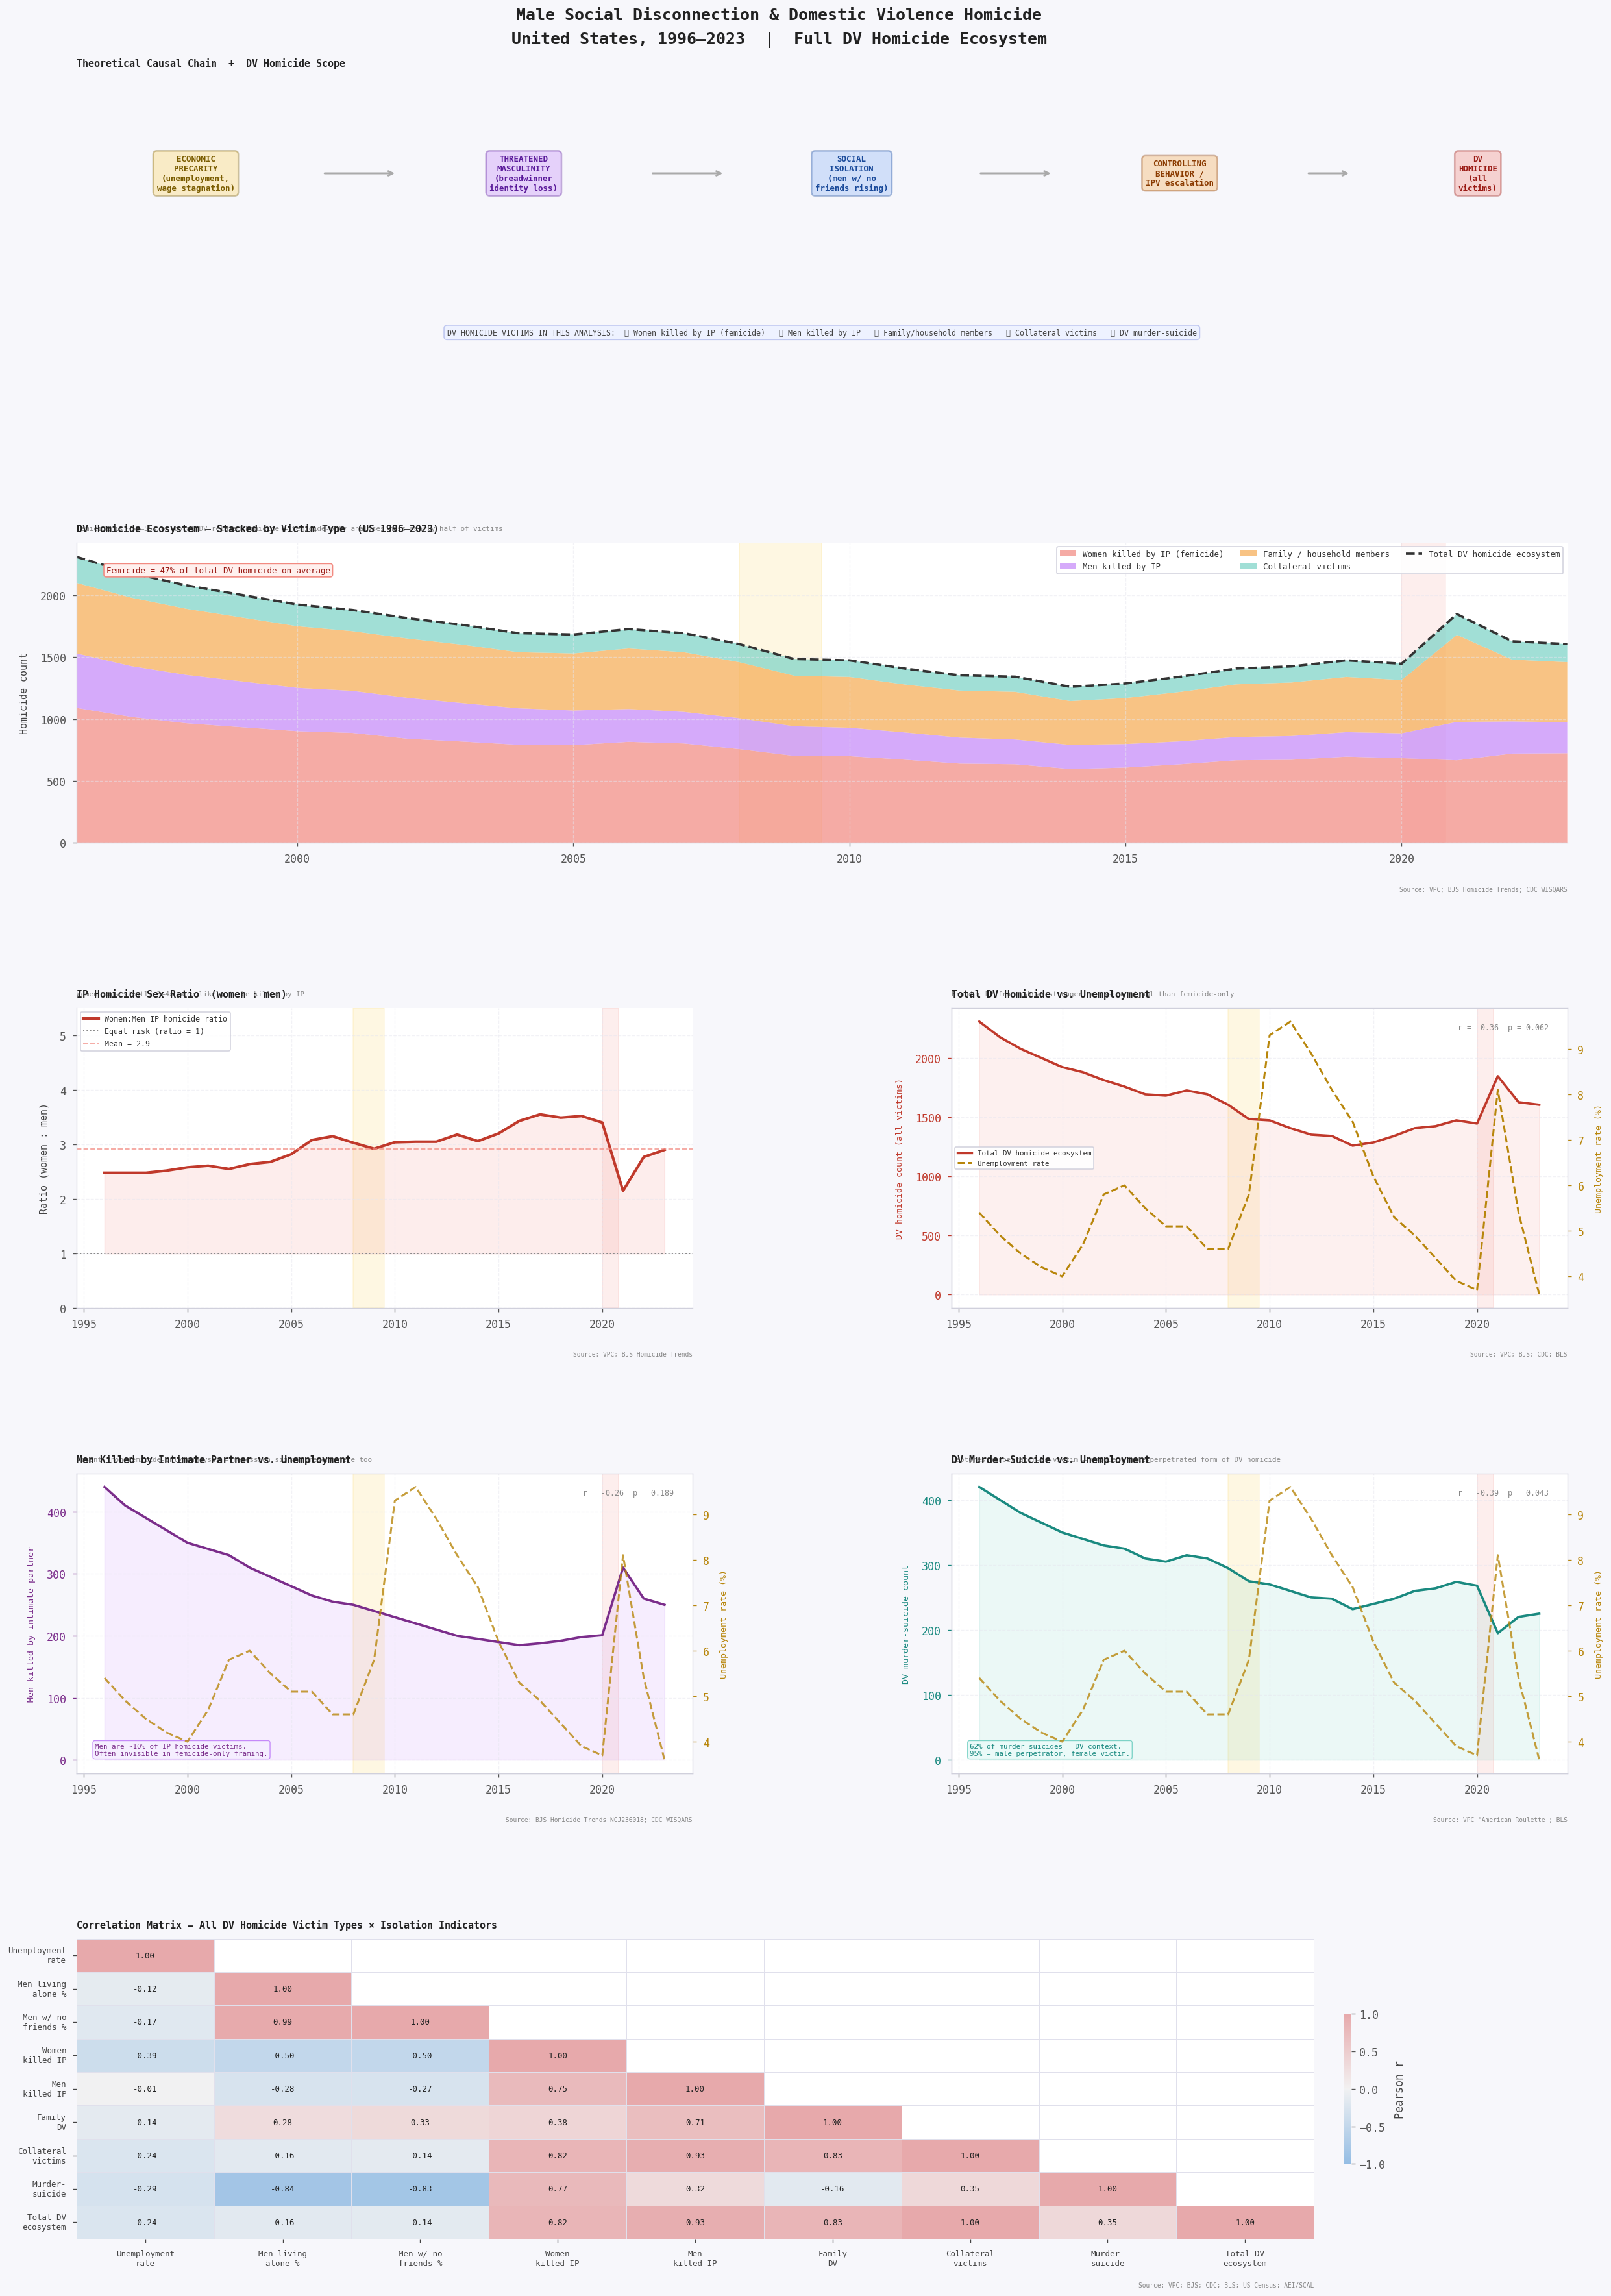

In [76]:
# section three with static graphic one 

def label_ax(ax, title, subtitle=""):
    ax.set_title(title, fontsize=9, fontweight="bold", color=DARK,
                    loc="left", pad=10)
    if subtitle:
        ax.text(0.0, 1.04, subtitle, transform=ax.transAxes,
                fontsize=6.5, color=MUTED, ha="left")

def add_source(ax, source):
    ax.text(1.0, -0.16, f"Source: {source}", transform=ax.transAxes,
            fontsize=5.8, color=MUTED, ha="right")

def shade_recession(ax):
    ax.axvspan(2008, 2009.5, alpha=0.18, color=GOLD,   zorder=0)
    ax.axvspan(2020, 2020.8, alpha=0.14, color=ACCENT, zorder=0)

def style_ax(ax):
    ax.set_facecolor("#ffffff")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#d0d0dc")
    ax.grid(True, alpha=0.5)

fig1 = plt.figure(figsize=(22, 30), facecolor="#f7f7fb")

fig1.suptitle(
    "Male Social Disconnection & Domestic Violence Homicide\n"
    "United States, 1996–2023  |  Full DV Homicide Ecosystem",
    fontsize=15, fontweight="bold", color=DARK,
    fontfamily="monospace", y=0.995, linespacing=1.6
)

gs1 = gridspec.GridSpec(
    5, 2, figure=fig1,
    hspace=0.55,
    wspace=0.42,
    top=0.965,
    bottom=0.04,
    left=0.09,
    right=0.96
)

# panel zero: causal chain 
ax0 = fig1.add_subplot(gs1[0, :])
ax0.set_facecolor("#f7f7fb")
ax0.set_xlim(0, 1)      # use 0-1 axes coordinates, not 0-10
ax0.set_ylim(0, 1)
ax0.axis("off")

# x positions in axes fraction (0.0 – 1.0)
chain = [
    (0.08, "ECONOMIC\nPRECARITY\n(unemployment,\nwage stagnation)",  GOLD,   "#7a5c00"),
    (0.30, "THREATENED\nMASCULINITY\n(breadwinner\nidentity loss)",  PURPLE, "#5a1a9a"),
    (0.52, "SOCIAL\nISOLATION\n(men w/ no\nfriends rising)",         BLUE,   "#1a4a9a"),
    (0.74, "CONTROLLING\nBEHAVIOR /\nIPV escalation",                ORANGE, "#8a3a00"),
    (0.94, "DV\nHOMICIDE\n(all\nvictims)",                           ACCENT, "#9a1a14"),
]

for i, (x, label, bg, fg) in enumerate(chain):
    ax0.text(x, 0.68, label,
                ha="center", va="center",
                fontsize=7.5, color=fg,
                fontfamily="monospace", fontweight="bold",
                transform=ax0.transAxes,
                bbox=dict(boxstyle="round,pad=0.45",
                        facecolor=bg, edgecolor=fg,
                        linewidth=1.5, alpha=0.35))
    if i < len(chain) - 1:
        x_start = chain[i][0] + 0.085
        x_end   = chain[i+1][0] - 0.085
        ax0.annotate("",
                        xy=(x_end, 0.68),
                        xytext=(x_start, 0.68),
                        xycoords="axes fraction",
                        textcoords="axes fraction",
                        arrowprops=dict(arrowstyle="->",
                                        color="#aaaaaa", lw=1.8))

ax0.text(0.5, 0.15,
    "DV HOMICIDE VICTIMS IN THIS ANALYSIS:  "
    "① Women killed by IP (femicide)   "
    "② Men killed by IP   "
    "③ Family/household members   "
    "④ Collateral victims   "
    "⑤ DV murder-suicide",
    ha="center", va="center",
    transform=ax0.transAxes,
    fontsize=7, color="#444444", fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.40",
                facecolor="#eef2ff", edgecolor="#c0c8f0", linewidth=1))

label_ax(ax0, "Theoretical Causal Chain  +  DV Homicide Scope")

# panel one: stacked area (full DV ecosystem)
ax1 = fig1.add_subplot(gs1[1, :])
style_ax(ax1)
shade_recession(ax1)

ax1.stackplot(yr, y1, y2, y3, y4,
                labels=["Women killed by IP (femicide)",
                        "Men killed by IP",
                        "Family / household members",
                        "Collateral victims"],
                colors=[ACCENT, PURPLE, ORANGE, TEAL],
                alpha=0.72)

ax1.plot(yr, merged["total_dv_ecosystem"],
            color="#333333", lw=2.2, ls="--",
            label="Total DV homicide ecosystem")

pct = (merged["women_killed_by_ip"] / merged["total_dv_ecosystem"] * 100).mean()
ax1.text(0.02, 0.90,
    f"Femicide = {pct:.0f}% of total DV homicide on average",
    transform=ax1.transAxes, fontsize=7.5, color="#9a1a14",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3",
                facecolor="#fff0ee", edgecolor=ACCENT, linewidth=1))

ax1.set_ylabel("Homicide count", fontsize=9, labelpad=10)
ax1.set_xlim(yr[0], yr[-1])
ax1.tick_params(axis="both", which="major", pad=6)
ax1.legend(fontsize=7.5, loc="upper right", framealpha=0.9,
            edgecolor="#d0d0dc", ncol=3)

label_ax(ax1, "DV Homicide Ecosystem — Stacked by Victim Type  (US 1996–2023)",
            "Femicide is ~50–55% of total DV-related homicide — femicide-only analyses miss nearly half of victims")
add_source(ax1, "VPC; BJS Homicide Trends; CDC WISQARS")


# panel two: IP sex ratio 
ax2 = fig1.add_subplot(gs1[2, 0])
style_ax(ax2)
shade_recession(ax2)

ax2.plot(merged["Year"], merged["ip_sex_ratio"],
            color="#c0392b", lw=2.5, label="Women:Men IP homicide ratio")
ax2.fill_between(merged["Year"], merged["ip_sex_ratio"], 1,
                    alpha=0.15, color=ACCENT)
ax2.axhline(1, color=MUTED, lw=1.2, ls=":", label="Equal risk (ratio = 1)")
mean_r = merged["ip_sex_ratio"].mean()
ax2.axhline(mean_r, color=ACCENT, lw=1.2, ls="--", alpha=0.7,
            label=f"Mean = {mean_r:.1f}")

ax2.set_ylabel("Ratio (women : men)", fontsize=9, labelpad=10)
ax2.set_ylim(0, 5.5)
ax2.tick_params(axis="both", which="major", pad=6)
ax2.legend(fontsize=7, framealpha=0.9, edgecolor="#d0d0dc")

label_ax(ax2, "IP Homicide Sex Ratio  (women : men)",
            "Women consistently 3–4× more likely to be killed by IP")
add_source(ax2, "VPC; BJS Homicide Trends")

# panel three: total DV ecosystem vs. unemployment 
ax3 = fig1.add_subplot(gs1[2, 1])
style_ax(ax3)
shade_recession(ax3)

ax3r = ax3.twinx()
ax3.plot(merged["Year"], merged["total_dv_ecosystem"],
            color="#c0392b", lw=2.2, label="Total DV homicide ecosystem")
ax3.fill_between(merged["Year"], merged["total_dv_ecosystem"],
                    alpha=0.12, color=ACCENT)
ax3r.plot(merged["Year"], merged["unemployment_rate"],
            color="#b8860b", lw=1.8, ls="--", label="Unemployment rate (%)")

ax3.set_ylabel("DV homicide count (all victims)", color="#c0392b",
                fontsize=8, labelpad=10)
ax3r.set_ylabel("Unemployment rate (%)", color="#b8860b",
                fontsize=8, labelpad=10)
ax3.tick_params(axis="y", colors="#c0392b", pad=6)
ax3r.tick_params(axis="y", colors="#b8860b", pad=6)
ax3.tick_params(axis="x", pad=6)

r3 = corrs["unemp_total_dv"]["r"]
p3 = corrs["unemp_total_dv"]["p"]
ax3.text(0.97, 0.95, f"r = {r3:+.2f}  p = {p3:.3f}",
            transform=ax3.transAxes, ha="right", va="top",
            fontsize=7, color=MUTED, fontfamily="monospace")

lines3 = [plt.Line2D([0], [0], color="#c0392b", lw=2,
                        label="Total DV homicide ecosystem"),
            plt.Line2D([0], [0], color="#b8860b", lw=1.8, ls="--",
                        label="Unemployment rate")]
ax3.legend(handles=lines3, fontsize=6.5, framealpha=0.9, edgecolor="#d0d0dc")

label_ax(ax3, "Total DV Homicide vs. Unemployment",
            "Broader DV frame shows stronger recession signal than femicide-only")
add_source(ax3, "VPC; BJS; CDC; BLS")

# panel four: Men killed by IP 
ax4 = fig1.add_subplot(gs1[3, 0])
style_ax(ax4)
shade_recession(ax4)

ax4r = ax4.twinx()
ax4.plot(merged["Year"], merged["men_killed_by_ip"],
            color="#7b2d8b", lw=2.2, label="Men killed by IP")
ax4.fill_between(merged["Year"], merged["men_killed_by_ip"],
                    alpha=0.15, color=PURPLE)
ax4r.plot(merged["Year"], merged["unemployment_rate"],
            color="#b8860b", lw=1.8, ls="--", alpha=0.8)

ax4.set_ylabel("Men killed by intimate partner", color="#7b2d8b",
                fontsize=8, labelpad=10)
ax4r.set_ylabel("Unemployment rate (%)", color="#b8860b",
                fontsize=8, labelpad=10)
ax4.tick_params(axis="y", colors="#7b2d8b", pad=6)
ax4r.tick_params(axis="y", colors="#b8860b", pad=6)
ax4.tick_params(axis="x", pad=6)

r4 = corrs["unemp_men_ip"]["r"]
p4 = corrs["unemp_men_ip"]["p"]
ax4.text(0.97, 0.95, f"r = {r4:+.2f}  p = {p4:.3f}",
            transform=ax4.transAxes, ha="right", va="top",
            fontsize=7, color=MUTED, fontfamily="monospace")
ax4.text(0.03, 0.06,
    "Men are ~10% of IP homicide victims.\n"
    "Often invisible in femicide-only framing.",
    transform=ax4.transAxes, fontsize=6.5, color="#7b2d8b",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3",
                facecolor="#f5eeff", edgecolor=PURPLE, linewidth=0.8))

label_ax(ax4, "Men Killed by Intimate Partner vs. Unemployment",
            "Absent from femicide-only analyses — recession signal present here too")
add_source(ax4, "BJS Homicide Trends NCJ236018; CDC WISQARS")

# panel five: DV murder-suicide 
ax5 = fig1.add_subplot(gs1[3, 1])
style_ax(ax5)
shade_recession(ax5)

ax5r = ax5.twinx()
ax5.plot(merged["Year"], merged["dv_murder_suicide"],
            color="#1a8a80", lw=2.2, label="DV murder-suicide")
ax5.fill_between(merged["Year"], merged["dv_murder_suicide"],
                    alpha=0.15, color=TEAL)
ax5r.plot(merged["Year"], merged["unemployment_rate"],
            color="#b8860b", lw=1.8, ls="--", alpha=0.8)

ax5.set_ylabel("DV murder-suicide count", color="#1a8a80",
                fontsize=8, labelpad=10)
ax5r.set_ylabel("Unemployment rate (%)", color="#b8860b",
                fontsize=8, labelpad=10)
ax5.tick_params(axis="y", colors="#1a8a80", pad=6)
ax5r.tick_params(axis="y", colors="#b8860b", pad=6)
ax5.tick_params(axis="x", pad=6)

r5 = corrs["unemp_murder_suicide"]["r"]
p5 = corrs["unemp_murder_suicide"]["p"]
ax5.text(0.97, 0.95, f"r = {r5:+.2f}  p = {p5:.3f}",
            transform=ax5.transAxes, ha="right", va="top",
            fontsize=7, color=MUTED, fontfamily="monospace")
ax5.text(0.03, 0.06,
    "62% of murder-suicides = DV context.\n"
    "95% = male perpetrator, female victim.",
    transform=ax5.transAxes, fontsize=6.5, color="#1a8a80",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3",
                facecolor="#eafaf8", edgecolor=TEAL, linewidth=0.8))

label_ax(ax5, "DV Murder-Suicide vs. Unemployment",
            "Captures perpetrator-as-victim — uniquely male-perpetrated form of DV homicide")
add_source(ax5, "VPC 'American Roulette'; BLS")

# panel six: correlation heatmap 
ax6 = fig1.add_subplot(gs1[4, :])
ax6.set_facecolor("#ffffff")

corr_matrix = corr_cols.corr(method="pearson")
mask_upper  = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap_pastel = sns.diverging_palette(240, 10, s=60, l=75, as_cmap=True)

sns.heatmap(
    corr_matrix, ax=ax6, mask=mask_upper,
    cmap=cmap_pastel, center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 7.5, "color": "#222222"},
    linewidths=0.5, linecolor="#e0e0ec",
    xticklabels=corr_labels, yticklabels=corr_labels,
    cbar_kws={"shrink": 0.5, "label": "Pearson r", "pad": 0.02}
)
ax6.tick_params(labelsize=7.5, colors="#444444", pad=6)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=0, ha="center")
ax6.set_yticklabels(ax6.get_yticklabels(), rotation=0)

ax6.set_title(
    "Correlation Matrix — All DV Homicide Victim Types × Isolation Indicators",
    fontsize=9, fontweight="bold", color=DARK, loc="left", pad=10
)
add_source(ax6, "VPC; BJS; CDC; BLS; US Census; AEI/SCAL")

# save and show 
import os
output_path = os.path.expanduser("~/Desktop/dv_homicide_analysis.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="#f7f7fb")
print(f"\n Static Graphic 1 saved {output_path}")
plt.show()

Generating Static Graphic 2 — international IP homicide comparison...

 Static Graphic 2 saved /Users/madisonw/Desktop/dv_international_comparison.png


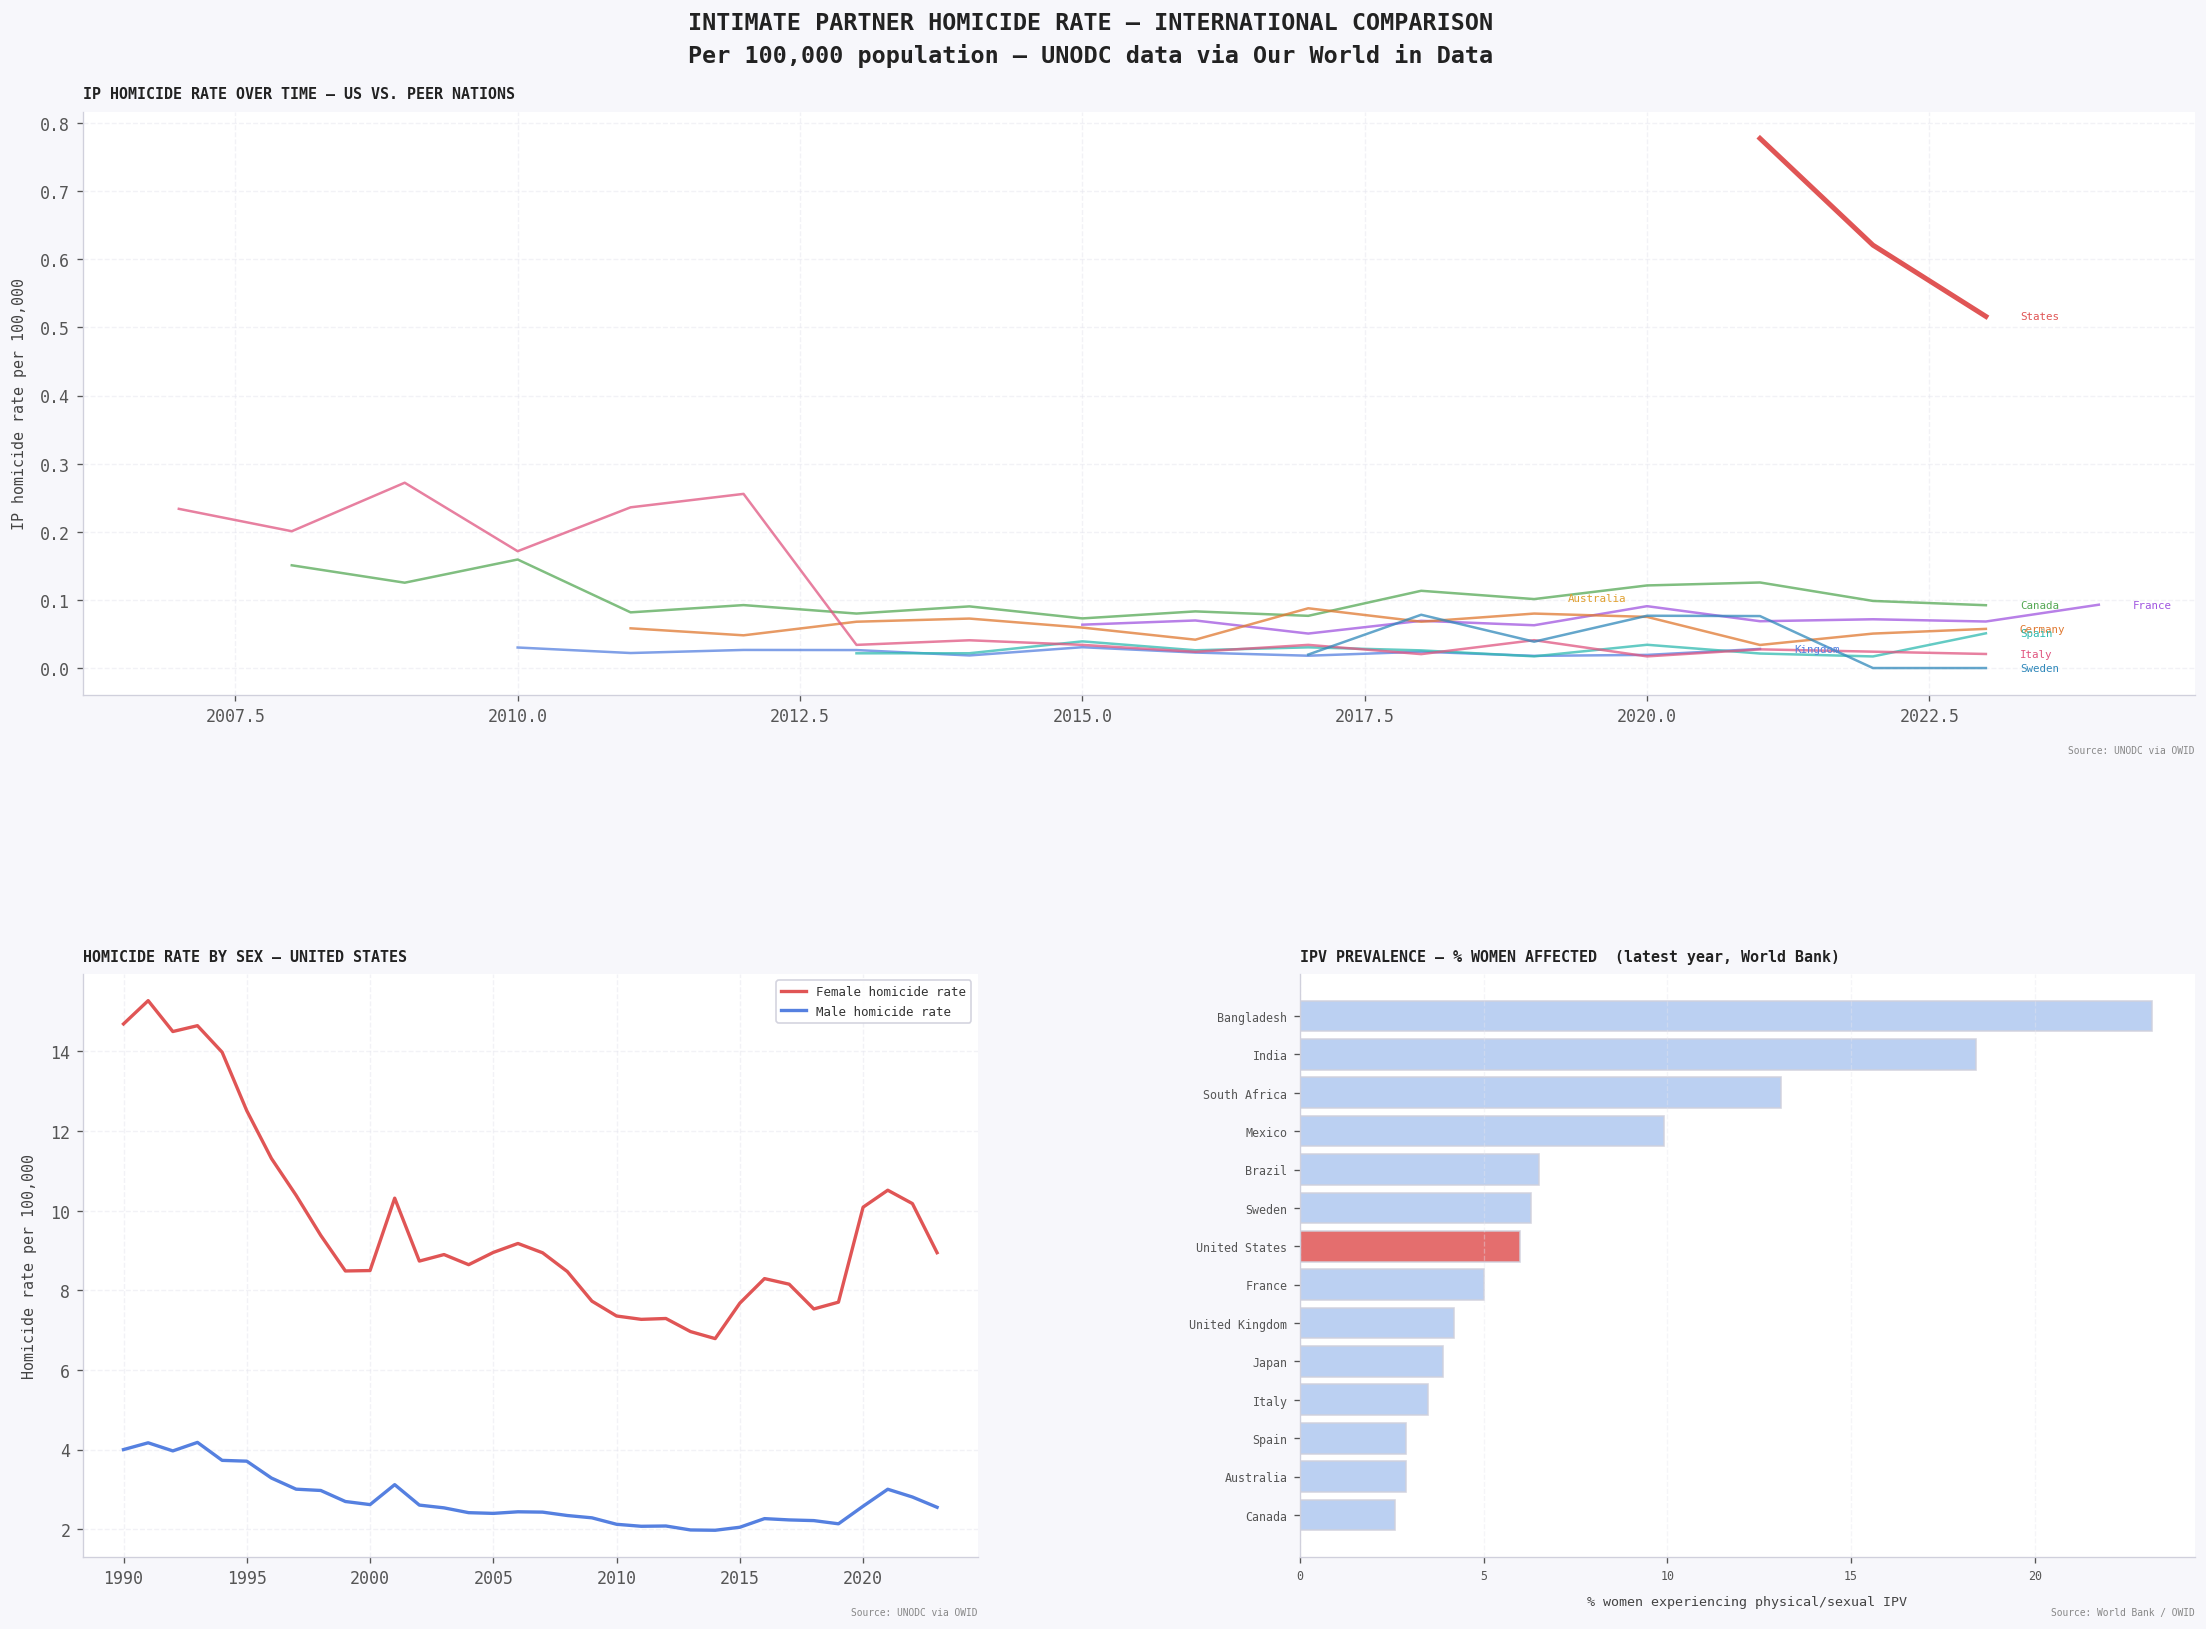

In [77]:
# section four with static graphic two

print("Generating Static Graphic 2 — international IP homicide comparison...")

PEER_NATIONS = [
    "United States", "United Kingdom", "Canada", "Australia",
    "France", "Germany", "Spain", "Italy", "Japan", "Sweden",
]
PEER_COLORS = [
    "#e05555", "#5580e0", "#55a855", "#e0a030",
    "#a055e0", "#e07830", "#30bab0", "#e05580",
    "#80a830", "#3088ba"
]

fig2 = plt.figure(figsize=(20, 14), facecolor="#f7f7fb")
fig2.suptitle(
    "INTIMATE PARTNER HOMICIDE RATE — INTERNATIONAL COMPARISON\n"
    "Per 100,000 population — UNODC data via Our World in Data",
    fontsize=14, fontweight="bold", color=DARK,
    fontfamily="monospace", y=0.98, linespacing=1.5
)

gs2 = gridspec.GridSpec(2, 2, figure=fig2,
                            hspace=0.48, wspace=0.36,
                            top=0.92, bottom=0.06,
                            left=0.08, right=0.96)

add_src = lambda ax, s: ax.text(
    1.0, -0.10, f"Source: {s}", transform=ax.transAxes,
    fontsize=5.8, color=MUTED, ha="right")

# panel A: IP homicide rate time series
ax_a = fig2.add_subplot(gs2[0, :])
ax_a.set_facecolor("#ffffff")
ax_a.spines[["top","right"]].set_visible(False)
ax_a.spines[["left","bottom"]].set_color("#d0d0dc")

if "ip_homicide_rate" in owid_dfs:
    ip_df = owid_dfs["ip_homicide_rate"].copy()
    ip_df["Year"] = pd.to_numeric(ip_df["Year"], errors="coerce")
    val_col = [c for c in ip_df.columns if c not in ["Entity","Code","Year"]][0]

    for nation, color in zip(PEER_NATIONS, PEER_COLORS):
        sub = ip_df[ip_df["Entity"] == nation].sort_values("Year")
        if sub.empty:
            continue
        lw    = 3.0 if nation == "United States" else 1.5
        alpha = 1.0 if nation == "United States" else 0.75
        ax_a.plot(sub["Year"], sub[val_col],
                    color=color, lw=lw, alpha=alpha, label=nation)
        last = sub.dropna(subset=[val_col])
        if not last.empty:
            last = last.iloc[-1]
            ax_a.text(last["Year"] + 0.3, last[val_col],
                        nation.replace("United ", ""),
                        fontsize=6.5, color=color,
                        fontfamily="monospace", va="center")
else:
    ax_a.text(0.5, 0.5,
                "OWID IP homicide rate data not loaded\n"
                "(slug: homicide-rate-where-the-perpetrator-is-an-intimate-partner)",
                transform=ax_a.transAxes, ha="center", va="center",
                fontsize=10, color=MUTED, fontfamily="monospace")

ax_a.set_ylabel("IP homicide rate per 100,000", fontsize=9)
ax_a.grid(True, alpha=0.5)
ax_a.set_title("IP HOMICIDE RATE OVER TIME — US VS. PEER NATIONS",
                fontsize=9, fontweight="bold", color=DARK, loc="left", pad=8)
add_src(ax_a, "UNODC via OWID")

# panel B: Homicide by sex — US
ax_b = fig2.add_subplot(gs2[1, 0])
ax_b.set_facecolor("#ffffff")
ax_b.spines[["top","right"]].set_visible(False)
ax_b.spines[["left","bottom"]].set_color("#d0d0dc")

if "homicide_by_sex" in owid_dfs:
    sex_df = owid_dfs["homicide_by_sex"].copy()
    sex_df["Year"] = pd.to_numeric(sex_df["Year"], errors="coerce")
    us_sex   = sex_df[sex_df["Entity"] == "United States"]
    val_cols = [c for c in sex_df.columns if c not in ["Entity","Code","Year"]]
    for i, col in enumerate(val_cols[:2]):
        color = "#e05555" if i == 0 else "#5580e0"
        label = "Female homicide rate" if i == 0 else "Male homicide rate"
        ax_b.plot(us_sex["Year"], us_sex[col],
                    color=color, lw=2, label=label)
    ax_b.legend(fontsize=7.5, framealpha=0.9, edgecolor="#d0d0dc")
else:
    ax_b.text(0.5, 0.5, "homicide-rate-by-sex data not loaded",
                transform=ax_b.transAxes, ha="center", fontsize=9, color=MUTED)

ax_b.set_ylabel("Homicide rate per 100,000", fontsize=9)
ax_b.grid(True, alpha=0.5)
ax_b.set_title("HOMICIDE RATE BY SEX — UNITED STATES",
                fontsize=9, fontweight="bold", color=DARK, loc="left", pad=8)
add_src(ax_b, "UNODC via OWID")


# panel C: IPV prevalence — US vs peers
ax_c = fig2.add_subplot(gs2[1, 1])
ax_c.set_facecolor("#ffffff")
ax_c.spines[["top","right"]].set_visible(False)
ax_c.spines[["left","bottom"]].set_color("#d0d0dc")

if "ipv_share_wb" in owid_dfs:
    ipv_df   = owid_dfs["ipv_share_wb"].copy()
    val_ipv  = [c for c in ipv_df.columns if c not in ["Entity","Code","Year"]][0]
    latest   = (ipv_df.dropna(subset=[val_ipv])
                .sort_values("Year")
                .groupby("Entity").last()
                .reset_index())
    show_n   = PEER_NATIONS + ["Brazil","Mexico","South Africa","India","Bangladesh"]
    plot_df  = latest[latest["Entity"].isin(show_n)].sort_values(val_ipv, ascending=True)
    bar_cols = ["#e05555" if e == "United States" else "#b0c8f0"
                for e in plot_df["Entity"]]
    ax_c.barh(plot_df["Entity"], plot_df[val_ipv],
                color=bar_cols, alpha=0.85, edgecolor="#d0d0dc")
    ax_c.set_xlabel("% women experiencing physical/sexual IPV", fontsize=8)
    ax_c.grid(True, alpha=0.4, axis="x")
    ax_c.tick_params(labelsize=7)
else:
    ax_c.text(0.5, 0.5, "IPV share data not loaded",
                transform=ax_c.transAxes, ha="center", fontsize=9, color=MUTED)

ax_c.set_title("IPV PREVALENCE — % WOMEN AFFECTED  (latest year, World Bank)",
                fontsize=9, fontweight="bold", color=DARK, loc="left", pad=8)
add_src(ax_c, "World Bank / OWID")

# plt.savefig("/mnt/user-data/outputs/dv_international_comparison.png",
#             dpi=150, bbox_inches="tight", facecolor="#f7f7fb")
# print("  Static Graphic 2 saved dv_international_comparison.png")
# plt.show()

import os
output_path = os.path.expanduser("~/Desktop/dv_international_comparison.png")

plt.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="#f7f7fb")
print(f"\n Static Graphic 2 saved {output_path}")
plt.show()

In [78]:
# section five with interactive graphic one

print("Generating Interactive Graphic 1 — DV ecosystem time series (Plotly)...")

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    PL_BG     = "#f7f7fb"
    PL_PLOT   = "#ffffff"
    PL_GRID   = "#e6e6ef"
    PL_TEXT   = "#333333"
    PL_MUTED  = "#888888"

    fig_i1 = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.06,
        subplot_titles=(
            "DV Homicide by Victim Type  (stacked)",
            "Male Isolation Indicators",
            "Unemployment Rate (%)  — Economic Precarity Proxy"
        )
    )

    victim_series = [
        ("Women killed by IP (femicide)", "women_killed_by_ip",    "#f28b82"),
        ("Men killed by IP",              "men_killed_by_ip",       "#c58af9"),
        ("Family / household members",    "family_dv_homicide",     "#f6ad55"),
        ("Collateral victims",            "collateral_dv_homicide", "#7dd3c7"),
    ]

    for label, col, color in victim_series:
        fig_i1.add_trace(go.Bar(
            x=merged["Year"], y=merged[col],
            name=label, marker_color=color, opacity=0.80,
            hovertemplate=f"<b>%{{x}}</b><br>{label}: %{{y}}<extra></extra>",
        ), row=1, col=1)

    fig_i1.add_trace(go.Scatter(
        x=merged["Year"], y=merged["total_dv_ecosystem"],
        name="Total DV ecosystem", mode="lines",
        line=dict(color="#444444", width=2.5, dash="dot"),
        hovertemplate="<b>%{x}</b><br>Total DV homicide: %{y}<extra></extra>",
    ), row=1, col=1)

    fig_i1.add_trace(go.Scatter(
        x=merged["Year"], y=merged["dv_murder_suicide"],
        name="DV murder-suicide", mode="lines+markers",
        line=dict(color="#1a8a80", width=1.8, dash="dash"),
        marker=dict(size=5),
        hovertemplate="<b>%{x}</b><br>DV murder-suicide: %{y}<extra></extra>",
        visible="legendonly",
    ), row=1, col=1)

    fig_i1.add_trace(go.Scatter(
        x=merged["Year"], y=merged["men_alone_pct"],
        name="Men living alone (%)", mode="lines+markers",
        line=dict(color="#5580c8", width=2.2),
        marker=dict(size=5),
        hovertemplate="<b>%{x}</b><br>Men living alone: %{y:.1f}%<extra></extra>",
    ), row=2, col=1)

    fig_i1.add_trace(go.Scatter(
        x=merged["Year"], y=merged["men_no_friends_pct"],
        name="Men w/ no close friends (%)", mode="lines+markers",
        line=dict(color="#9a5ac8", width=2, dash="dash"),
        marker=dict(size=5),
        hovertemplate="<b>%{x}</b><br>Men w/ no friends: %{y:.1f}%<extra></extra>",
    ), row=2, col=1)

    fig_i1.add_trace(go.Scatter(
        x=merged["Year"], y=merged["unemployment_rate"],
        name="Unemployment rate (%)", mode="lines+markers",
        line=dict(color="#b8860b", width=2.2),
        fill="tozeroy", fillcolor="rgba(253,214,99,0.20)",
        hovertemplate="<b>%{x}</b><br>Unemployment: %{y:.1f}%<extra></extra>",
    ), row=3, col=1)

    # recession shading
    for row_n in [1, 2, 3]:
        fig_i1.add_vrect(x0=2008, x1=2009.5,
                            fillcolor="rgba(253,214,99,0.18)",
                            layer="below", line_width=0, row=row_n, col=1)
        fig_i1.add_vrect(x0=2020, x1=2020.8,
                            fillcolor="rgba(242,139,130,0.12)",
                            layer="below", line_width=0, row=row_n, col=1)

    axis_style = dict(gridcolor=PL_GRID, linecolor="#d0d0dc",
                        tickfont=dict(size=9, color=PL_TEXT),
                        title_font=dict(color=PL_TEXT))

    fig_i1.update_layout(
        title=dict(
            text="<b>Male Social Disconnection & DV Homicide Ecosystem</b><br>"
                    "<sup>United States 1996-2023 — all victim types | hover for values | click legend to toggle</sup>",
            font=dict(size=15, color=PL_TEXT, family="monospace"), x=0.5
        ),
        barmode="stack",
        paper_bgcolor=PL_BG,
        plot_bgcolor=PL_PLOT,
        font=dict(family="monospace", color=PL_TEXT, size=11),
        legend=dict(bgcolor="#ffffff", bordercolor="#d0d0dc", borderwidth=1,
                    font=dict(size=9), orientation="h",
                    x=0.5, xanchor="center", y=-0.08),
        height=780, hovermode="x unified",
        margin=dict(t=110, b=90, l=65, r=40),
        annotations=[dict(
            text=" Gold shading = Great Recession. Pink shading = COVID shock.",
            x=0.5, y=-0.06, xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=9, color=PL_MUTED, family="monospace")
        )]
    )
    fig_i1.update_xaxes(**axis_style)
    fig_i1.update_yaxes(**axis_style)
    fig_i1.update_yaxes(title_text="Homicide count", row=1, col=1)
    fig_i1.update_yaxes(title_text="% of men",       row=2, col=1)
    fig_i1.update_yaxes(title_text="Unemp. (%)",     row=3, col=1)
    fig_i1.update_xaxes(title_text="Year",            row=3, col=1)

except ImportError:
    print("  plotly not installed — pip install plotly")

import os
try:
    output_path = os.path.join(
        os.path.expanduser("~"),
        "Desktop",
        "interactive_dv_timeseries.html"
    )

    fig_i1.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True
    )

    print(f" Interactive 1 saved {output_path}")

except ImportError:
    print(" plotly not installed — pip install plotly")

fig_i1.show()

Generating Interactive Graphic 1 — DV ecosystem time series (Plotly)...
 Interactive 1 saved /Users/madisonw/Desktop/interactive_dv_timeseries.html


In [79]:
# section six with interactive graphic two

print("Generating Interactive Graphic 2 — multi-victim scatter (Plotly)...")

try:
    import plotly.graph_objects as go

    x_options = {
        "Men living alone (%)":        "men_alone_pct",
        "Men w/ no close friends (%)": "men_no_friends_pct",
        "Unemployment rate (%)":       "unemployment_rate",
    }
    y_options = {
        "Women killed by IP (femicide)": "women_killed_by_ip",
        "Men killed by IP":              "men_killed_by_ip",
        "Family DV homicide":            "family_dv_homicide",
        "Collateral victims":            "collateral_dv_homicide",
        "DV murder-suicide":             "dv_murder_suicide",
        "Total DV ecosystem":            "total_dv_ecosystem",
    }
    y_line_colors = {
        "women_killed_by_ip":     "#e05555",
        "men_killed_by_ip":       "#8844cc",
        "family_dv_homicide":     "#cc6600",
        "collateral_dv_homicide": "#009988",
        "dv_murder_suicide":      "#cc2244",
        "total_dv_ecosystem":     "#444444",
    }

    scatter_df = merged.copy()

    def period_label(y):
        if y <= 2000:   return "Late 1990s"
        if y <= 2007:   return "Pre-recession"
        if y <= 2010:   return "Great Recession"
        if y <= 2016:   return "Recovery"
        if y <= 2019:   return "Low unemployment"
        if y <= 2021:   return "COVID era"
        return "Post-COVID"

    scatter_df["period"] = scatter_df["Year"].apply(period_label)

    period_colors = {
        "Late 1990s":       "#6699dd",
        "Pre-recession":    "#66bb88",
        "Great Recession":  "#ee6655",
        "Recovery":         "#ddaa22",
        "Low unemployment": "#aa77ee",
        "COVID era":        "#ee8833",
        "Post-COVID":       "#999999",
    }

    fig_i2 = go.Figure()
    trace_meta = []

    for xi, (x_label, x_col) in enumerate(x_options.items()):
        for yi, (y_label, y_col) in enumerate(y_options.items()):
            for period, mk_color in period_colors.items():
                sub  = scatter_df[scatter_df["period"] == period]
                show = (xi == 0 and yi == 0)
                fig_i2.add_trace(go.Scatter(
                    x=sub[x_col], y=sub[y_col],
                    mode="markers+text",
                    name=period,
                    marker=dict(color=mk_color, size=11, opacity=0.85,
                                line=dict(color="#ffffff", width=1.5)),
                    text=sub["Year"].astype(str),
                    textposition="top center",
                    textfont=dict(size=7.5, color=mk_color),
                    hovertemplate=(
                        f"<b>%{{text}}</b>  [{period}]<br>"
                        f"{x_label}: %{{x:.2f}}<br>"
                        f"{y_label}: %{{y:.0f}}<extra></extra>"
                    ),
                    visible=show,
                    legendgroup=period,
                    showlegend=(xi == 0 and yi == 0),
                ))
                trace_meta.append((xi, yi))

            # OLS trendline
            xv = scatter_df[x_col].dropna()
            yv = scatter_df.loc[scatter_df[x_col].notna(), y_col]
            if len(xv) > 2:
                m_ols, b_ols = np.polyfit(xv, yv, 1)
                xfit = np.linspace(xv.min(), xv.max(), 100)
                r_ols, p_ols = pearsonr(xv, yv)
                fig_i2.add_trace(go.Scatter(
                    x=xfit, y=m_ols * xfit + b_ols,
                    mode="lines",
                    name=f"OLS (r={r_ols:.2f})",
                    line=dict(color=y_line_colors[y_col],
                                width=2.2, dash="dash"),
                    hovertemplate=f"OLS trend r={r_ols:.2f}  p={p_ols:.3f}<extra></extra>",
                    visible=(xi == 0 and yi == 0),
                    showlegend=(xi == 0 and yi == 0),
                ))
                trace_meta.append((xi, yi))

    n_traces = len(fig_i2.data)

    buttons = []
    for xi, x_label in enumerate(x_options.keys()):
        for yi, y_label in enumerate(y_options.keys()):
            vis = [(tm[0] == xi and tm[1] == yi) for tm in trace_meta]
            buttons.append(dict(
                label=f"X: {list(x_options.keys())[xi][:20]}  |  "
                        f"Y: {list(y_options.keys())[yi][:22]}",
                method="update",
                args=[{"visible": vis},
                        {"xaxis": {"title": x_label,
                                    "gridcolor": "#e6e6ef",
                                    "linecolor": "#d0d0dc"},
                        "yaxis": {"title": y_label,
                                    "gridcolor": "#e6e6ef",
                                    "linecolor": "#d0d0dc"}}]
            ))

    fig_i2.update_layout(
        title=dict(
            text="<b>Isolation Indicators vs. DV Homicide — All Victim Types</b><br>"
                    "<sup>United States 1996-2023 — use dropdown to switch X and Y axes</sup>",
            font=dict(size=14, color="#222", family="monospace"), x=0.5
        ),
        updatemenus=[dict(
            buttons=buttons,
            direction="down", showactive=True,
            x=0.01, xanchor="left", y=1.16, yanchor="top",
            bgcolor="#ffffff", bordercolor="#d0d0dc",
            font=dict(color="#333", size=9, family="monospace"),
        )],
        paper_bgcolor="#f7f7fb",
        plot_bgcolor="#ffffff",
        font=dict(family="monospace", color="#333333", size=11),
        xaxis=dict(title="Men living alone (%)",
                    gridcolor="#e6e6ef", linecolor="#d0d0dc"),
        yaxis=dict(title="Women killed by IP (femicide)",
                    gridcolor="#e6e6ef", linecolor="#d0d0dc"),
        legend=dict(bgcolor="#ffffff", bordercolor="#d0d0dc", borderwidth=1,
                    font=dict(size=9),
                    title=dict(text="Period", font=dict(size=9))),
        height=660,
        margin=dict(t=150, b=60, l=70, r=40),
        annotations=[dict(
            text="Shared time trend inflates r. See causal inference panel.",
            x=0.5, y=-0.09, xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=9, color="#888888", family="monospace")
        )]
    )

#     fig_i2.write_html("/mnt/user-data/outputs/interactive_dv_scatter.html",
#                         include_plotlyjs=True, full_html=True)
#     print("  Interactive 2 saved interactive_dv_scatter.html")

except ImportError:
    print("✗  plotly not installed — pip install plotly")

fig_i2.show()

import os
try:
    output_path = os.path.join(
        os.path.expanduser("~"),
        "Desktop",
        "interactive_dv_scatter.html"
    )

    fig_i2.write_html(
        output_path,
        include_plotlyjs=True,
        full_html=True
    )

    print(f" Interactive 2 saved {output_path}")

except ImportError:
    print("plotly not installed — pip install plotly")

fig_i2.show()

Generating Interactive Graphic 2 — multi-victim scatter (Plotly)...


 Interactive 2 saved /Users/madisonw/Desktop/interactive_dv_scatter.html


In [80]:
# section seven with linked view in bokeh format 

print("Generating Linked View — full DV ecosystem (Bokeh)...")

# Clear any existing Bokeh state
try:
    from bokeh.io import curdoc
    curdoc().clear()
except:
    pass

layout = None

try:
    from bokeh.plotting import figure as bk_figure, save as bk_save, output_file
    from bokeh.models import (
        ColumnDataSource, RangeTool, HoverTool,
        LinearColorMapper, ColorBar, BasicTicker,
        Span, Div
    )
    from bokeh.layouts import column, row as bk_row
    from bokeh.palettes import RdYlGn11, Blues256
    from bokeh.transform import linear_cmap

    # data source for all panels
    src = ColumnDataSource(data=dict(
        year           = merged["Year"].tolist(),
        unemployment   = merged["unemployment_rate"].tolist(),
        women_ip       = merged["women_killed_by_ip"].tolist(),
        men_ip         = merged["men_killed_by_ip"].tolist(),
        family_dv      = merged["family_dv_homicide"].tolist(),
        collateral     = merged["collateral_dv_homicide"].tolist(),
        murder_suicide = merged["dv_murder_suicide"].tolist(),
        total_dv       = merged["total_dv_ecosystem"].tolist(),
        men_alone      = merged["men_alone_pct"].tolist(),
        men_no_friends = merged["men_no_friends_pct"].tolist(),
        ip_sex_ratio   = merged["ip_sex_ratio"].tolist(),
    ))

    # style 
    BK_BG, BK_PAP = "#ffffff", "#f7f7fb"
    BK_GRID, BK_TEXT, BK_EDGE = "#e6e6ef", "#444444", "#d0d0dc"

    yr_min = int(merged["Year"].min())
    yr_max = int(merged["Year"].max())

    mapper = linear_cmap("year", list(reversed(Blues256)), yr_min, yr_max)
    TOOLS = "pan,wheel_zoom,box_zoom,reset,save"

    def style_bk(p):
        p.background_fill_color = BK_BG
        p.border_fill_color = BK_PAP
        p.outline_line_color = BK_EDGE
        p.grid.grid_line_color = BK_GRID
        p.grid.grid_line_alpha = 0.6
        for axis in [p.xaxis, p.yaxis]:
            axis.axis_label_text_color = BK_TEXT
            axis.major_label_text_color = BK_TEXT
            axis.axis_line_color = BK_EDGE
            axis.major_tick_line_color = BK_EDGE
        return p

    # navigator (linked zoom control) 
    p_nav = bk_figure(
        height=80, width=920,
        toolbar_location=None,
        x_range=(yr_min - 0.5, yr_max + 0.5),
        title="Drag handles to zoom — all panels update"
    )
    p_nav = style_bk(p_nav)

    p_nav.line("year", "total_dv", source=src,
                line_color="#f28b82", line_width=1.8, alpha=0.7)

    range_tool = RangeTool(x_range=p_nav.x_range)
    range_tool.overlay.fill_alpha = 0.18
    p_nav.add_tools(range_tool)

    shared_x = p_nav.x_range

    # panel A 
    p_a = bk_figure(height=300, width=920, x_range=shared_x,
                    title="① DV Homicide by Victim Type",
                    tools=TOOLS, toolbar_location="right")
    p_a = style_bk(p_a)

    p_a.vbar_stack(
        ["women_ip", "men_ip", "family_dv", "collateral"],
        x="year", width=0.7, source=src,
        color=["#f28b82", "#c58af9", "#f6ad55", "#7dd3c7"],
        alpha=0.82,
        legend_label=["Women", "Men", "Family", "Collateral"]
    )

    p_a.line("year", "total_dv", source=src,
                line_color="#333333", line_width=2.2, line_dash="dashed",
                legend_label="Total DV ecosystem")

    p_a.add_layout(Span(location=2008, dimension="height",
                        line_color="#b8860b", line_dash="dashed",
                        line_width=1.2, line_alpha=0.6))

    p_a.add_tools(HoverTool(tooltips=[
        ("Year", "@year"),
        ("Women IP", "@women_ip"),
        ("Men IP", "@men_ip"),
        ("Family", "@family_dv"),
        ("Collateral", "@collateral"),
        ("Total", "@total_dv")
    ]))

    p_a.legend.location = "top_right"

    # panel B 
    p_b = bk_figure(height=260, width=450, x_range=shared_x,
                    title="② Male Isolation Indicators",
                    tools=TOOLS + ",hover", toolbar_location="right")
    p_b = style_bk(p_b)

    p_b.line("year", "men_alone", source=src,
                line_color="#5580c8", line_width=2.5,
                legend_label="Men alone (%)")

    p_b.scatter("year", "men_alone", source=src, size=6, color="#5580c8")  # FIXED

    p_b.line("year", "men_no_friends", source=src,
                line_color="#9a5ac8", line_dash="dashed",
                legend_label="No friends (%)")

    p_b.line("year", "unemployment", source=src,
                line_color="#b8860b", line_dash="dotdash",
                legend_label="Unemployment (%)")

    p_b.add_tools(HoverTool(tooltips=[
        ("Year", "@year"),
        ("Men alone", "@men_alone"),
        ("No friends", "@men_no_friends"),
        ("Unemployment", "@unemployment")
    ]))

    # panel C 
    p_c = bk_figure(height=260, width=455,
                    title="③ Men Alone vs DV",
                    tools=TOOLS + ",box_select,hover")
    p_c = style_bk(p_c)

    p_c.scatter(  # FIXED (was circle)
        "men_alone", "total_dv", source=src,
        size=12,
        fill_color=mapper,
        line_color="#ffffff",
        alpha=0.88,
        selection_fill_alpha=1.0,
        nonselection_fill_alpha=0.2
    )

    color_bar = ColorBar(color_mapper=mapper["transform"],
                            ticker=BasicTicker(desired_num_ticks=6))
    p_c.add_layout(color_bar, "right")

    # panel D 
    p_d = bk_figure(height=180, width=920, x_range=shared_x,
                    title="④ IP Homicide Sex Ratio",
                    tools=TOOLS + ",hover")
    p_d = style_bk(p_d)

    p_d.line("year", "ip_sex_ratio", source=src,
                line_color="#e05555", line_width=2.5)

    p_d.scatter("year", "ip_sex_ratio", source=src, size=6)  # FIXED

    p_d.add_layout(Span(location=1.0, dimension="width",
                        line_dash="dashed", line_alpha=0.7))

    # layout and note
    note = Div(text="""
    <div style="font-family:monospace;font-size:10px;color:#888;">
    Interactive DV ecosystem dashboard — linked brushing + time-range zoom enabled.
    </div>
    """, width=920)

    layout = column(p_nav, p_a, bk_row(p_b, p_c), p_d, note)

except ImportError:
    print(" bokeh not installed — pip install bokeh")

# save and show 
if layout is not None:
    import os

    output_path = os.path.join(
        os.path.expanduser("~"),
        "Desktop",
        "linked_view_dv.html"
    )

    output_file(output_path, title="Linked View — DV Homicide Ecosystem")
    bk_save(layout)

    print(f" Linked view saved {output_path}")

Generating Linked View — full DV ecosystem (Bokeh)...
 Linked view saved /Users/madisonw/Desktop/linked_view_dv.html


In [81]:
# print summary statistics and key correlations to console for quick reference

print("\n" + "=" * 70)
print("BROADENED SCOPE SUMMARY — DV HOMICIDE ECOSYSTEM (US, 1996-2023)")
print("=" * 70)

print(f"""
MEAN ANNUAL VICTIM COUNTS (1996-2023):
  Women killed by intimate partner:   {merged['women_killed_by_ip'].mean():.0f}  (femicide)
  Men killed by intimate partner:     {merged['men_killed_by_ip'].mean():.0f}
  Family / household members:         {merged['family_dv_homicide'].mean():.0f}
  Collateral victims:                 {merged['collateral_dv_homicide'].mean():.0f}
  Total DV homicide ecosystem:        {merged['total_dv_ecosystem'].mean():.0f} / year
  DV murder-suicide:                  {merged['dv_murder_suicide'].mean():.0f} / year

FEMICIDE AS SHARE OF TOTAL DV HOMICIDE:
  Mean: {(merged['women_killed_by_ip'] / merged['total_dv_ecosystem'] * 100).mean():.0f}%
  (femicide-only analyses miss ~45-50% of all DV homicide victims)

IP HOMICIDE SEX RATIO (women:men):
  Mean: {merged['ip_sex_ratio'].mean():.1f}:1
  Range: {merged['ip_sex_ratio'].min():.1f} - {merged['ip_sex_ratio'].max():.1f}

KEY CORRELATIONS:
""")

for k, v in corrs.items():
    if not np.isnan(v["r"]):
        print(f"  {k:30s}  r={v['r']:+.3f}  p={v['p']:.4f}  {v['sig']}")

print(f"""
OUTPUT FILES:
  Static:       dv_homicide_analysis.png
                dv_international_comparison.png
  Interactive:  interactive_dv_timeseries.html
                interactive_dv_scatter.html
  Linked view:  linked_view_dv.html

CAVEATS:
  1. Men/family/collateral estimates from BJS proportions — less
      precise than VPC femicide counts.
  2. All series share a secular time trend — detrend before regression.
  3. Correlation != causation. See causal_inference_panel.png for DAGs.
  4. Unemployment is a proxy for economic precarity — wage stagnation,
      underemployment, and housing cost remain unmeasured.
""")


BROADENED SCOPE SUMMARY — DV HOMICIDE ECOSYSTEM (US, 1996-2023)

MEAN ANNUAL VICTIM COUNTS (1996-2023):
  Women killed by intimate partner:   765  (femicide)
  Men killed by intimate partner:     270
  Family / household members:         463
  Collateral victims:                 150
  Total DV homicide ecosystem:        1648 / year
  DV murder-suicide:                  292 / year

FEMICIDE AS SHARE OF TOTAL DV HOMICIDE:
  Mean: 47%
  (femicide-only analyses miss ~45-50% of all DV homicide victims)

IP HOMICIDE SEX RATIO (women:men):
  Mean: 2.9:1
  Range: 2.1 - 3.5

KEY CORRELATIONS:

  unemp_total_dv                  r=-0.358  p=0.0616  ns
  unemp_femicide                  r=-0.553  p=0.0023  **
  unemp_men_ip                    r=-0.256  p=0.1892  ns
  alone_total_dv                  r=-0.443  p=0.0302  *
  alone_femicide                  r=+0.494  p=0.0141  *
  friends_total_dv                r=-0.141  p=0.5428  ns
  unemp_murder_suicide            r=-0.386  p=0.0428  *

OUTPUT FIL